This project uses official UK automotive datasets to understand and model manufacturer performance in the 2024–2025 car market. I combine the SMMT 2025 new‑car registration snapshot (by marque) with the DfT df_VEH0160_UK file, which reports vehicles registered for the first time by body type, make, generic model and model each quarter. The notebook starts by cleaning and reshaping these sources into analysis‑ready tables, then applies exploratory data analysis, feature engineering and machine‑learning models to classify high‑ vs low‑sales manufacturers and to detect strong growth quarters for each make.

https://www.gov.uk/government/statistical-data-sets/vehicle-licensing-statistics-data-files

All code, intermediate datasets and figures are stored in my GitHub repository “SMMT‑2025‑UK‑Car‑Sales‑Analysis”:
https://github.com/SunkeAnandasai3784/SMMT-2025-UK-Car-Sales-Analysis.
​

The aim of the project is to build transparent, data‑driven models that (1) classify manufacturers into high and low performers based on SMMT registration volumes and market shares, and (2) predict whether a manufacturer experiences strong year‑on‑year growth in new registrations using time‑series features from df_VEH0160_UK.

DfT VEH0160 – loading and reshaping to a panel

In [1]:
# ============================================================
# 0. Imports and settings
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score, recall_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, log_loss, roc_curve
)

sns.set(style="whitegrid")
eps = 1e-6


In [3]:
# ============================================================
# 1. Load VEH0160 data
# ============================================================
df_veh0160_uk = pd.read_csv("/content/df_VEH0160_UK.csv", encoding="latin1")
print("Raw shape:", df_veh0160_uk.shape)
print(df_veh0160_uk.columns)

Raw shape: (61226, 50)
Index(['BodyType', 'Make', 'GenModel', 'Model', 'Fuel', '2025 Q3', '2025 Q2',
       '2025 Q1', '2024 Q4', '2024 Q3', '2024 Q2', '2024 Q1', '2023 Q4',
       '2023 Q3', '2023 Q2', '2023 Q1', '2022 Q4', '2022 Q3', '2022 Q2',
       '2022 Q1', '2021 Q4', '2021 Q3', '2021 Q2', '2021 Q1', '2020 Q4',
       '2020 Q3', '2020 Q2', '2020 Q1', '2019 Q4', '2019 Q3', '2019 Q2',
       '2019 Q1', '2018 Q4', '2018 Q3', '2018 Q2', '2018 Q1', '2017 Q4',
       '2017 Q3', '2017 Q2', '2017 Q1', '2016 Q4', '2016 Q3', '2016 Q2',
       '2016 Q1', '2015 Q4', '2015 Q3', '2015 Q2', '2015 Q1', '2014 Q4',
       '2014 Q3'],
      dtype='object')


In [4]:
# ============================================================
# 2. Filter to Cars and reshape to long format (Make × Period)
# ============================================================
cars = df_veh0160_uk[df_veh0160_uk["BodyType"] == "Cars"].copy()
print("Cars shape:", cars.shape)

# Quarter columns like "2014 Q3"
quarter_cols = [
    c for c in cars.columns
    if "Q" in c and any(str(y) in c for y in range(2000, 2035))
]
print("Number of quarter columns:", len(quarter_cols))

df_long = cars.melt(
    id_vars=["Make"],
    value_vars=quarter_cols,
    var_name="Period",
    value_name="Registered"
)

df_long = df_long.dropna(subset=["Registered"])
df_long["Registered"] = df_long["Registered"].astype(float)

# Extract Year and QuarterNo from "YYYY Qn"
df_long[["Year", "QuarterNo"]] = df_long["Period"].str.extract(r"(\d{4})\s*Q(\d)")
df_long["Year"] = df_long["Year"].astype(int)
df_long["QuarterNo"] = df_long["QuarterNo"].astype(int)

# End-of-quarter date
quarter_end_month = {1: 3, 2: 6, 3: 9, 4: 12}
df_long["Month"] = df_long["QuarterNo"].map(quarter_end_month)
df_long["Date"] = pd.to_datetime(
    dict(year=df_long["Year"], month=df_long["Month"], day=1)
) + pd.offsets.MonthEnd(0)

print("Long shape:", df_long.shape)
df_long.head()


Cars shape: (32832, 50)
Number of quarter columns: 45
Long shape: (1477440, 7)


,Make,Period,Registered,Year,QuarterNo,Month,Date
0,ABARTH,2025 Q3,0.0,2025,3,9,2025-09-30
1,ABARTH,2025 Q3,0.0,2025,3,9,2025-09-30
2,ABARTH,2025 Q3,2.0,2025,3,9,2025-09-30
3,ABARTH,2025 Q3,0.0,2025,3,9,2025-09-30
4,ABARTH,2025 Q3,0.0,2025,3,9,2025-09-30


In [5]:
# ============================================================
# 3. Aggregate to Make × Date and create lags
# ============================================================
panel = (
    df_long
    .groupby(["Make", "Date"], as_index=False)["Registered"]
    .sum()
    .sort_values(["Make", "Date"])
)

group_keys = ["Make"]

panel["Registered_lag1"] = panel.groupby(group_keys)["Registered"].shift(1)
panel["Registered_lag2"] = panel.groupby(group_keys)["Registered"].shift(2)
panel["Registered_lag4"] = panel.groupby(group_keys)["Registered"].shift(4)

panel["MA3"] = (
    panel
    .groupby(group_keys)["Registered"]
    .rolling(3)
    .mean()
    .reset_index(level=0, drop=True)
)

panel = panel.dropna(subset=["Registered_lag1", "Registered_lag4", "MA3"])
print("Panel after lags:", panel.shape)
panel.head()

Panel after lags: (14842, 7)


,Make,Date,Registered,Registered_lag1,Registered_lag2,Registered_lag4,MA3
4,ABARTH,2015-09-30,928.0,538.0,510.0,477.0,658.666667
5,ABARTH,2015-12-31,702.0,928.0,538.0,346.0,722.666667
6,ABARTH,2016-03-31,1015.0,702.0,928.0,510.0,881.666667
7,ABARTH,2016-06-30,954.0,1015.0,702.0,538.0,890.333333
8,ABARTH,2016-09-30,1099.0,954.0,1015.0,928.0,1022.666667


In [6]:
# ============================================================
# 4. Engineered features (growth, volatility, market share)
# ============================================================
# Year-on-year growth rate (used ONLY for target / diagnostics)
panel["YoY_Growth_Rate"] = (
    (panel["Registered"] - panel["Registered_lag4"]) /
    (panel["Registered_lag4"] + eps)
)

# Quarter-on-quarter growth rate (model input)
panel["QoQ_Growth_Rate"] = (
    (panel["Registered"] - panel["Registered_lag1"]) /
    (panel["Registered_lag1"] + eps)
)

# Volatility of last 4 quarters (model input)
panel["Volatility"] = (
    panel
    .groupby(group_keys)["Registered"]
    .rolling(4)
    .std()
    .reset_index(level=0, drop=True)
)

# Market share (model input)
total_market = panel.groupby("Date")["Registered"].transform("sum")
panel["Market_Share"] = panel["Registered"] / (total_market + eps)

panel = panel.dropna(
    subset=["YoY_Growth_Rate", "QoQ_Growth_Rate",
            "Volatility", "Market_Share"]
)
print("Panel after engineered features:", panel.shape)


Panel after engineered features: (13756, 11)


In [7]:
from IPython.display import display, Image
import os

# Display all PNG images in /content
png_files = [f for f in os.listdir('/content') if f.endswith('.png')]
for f in sorted(png_files):
    print(f'=== {f} ===')
    display(Image(filename=f'/content/{f}'))

In [8]:
# ============================================================
# 5. Strong-growth target (label) – uses YoY_Growth_Rate
#    but YoY_Growth_Rate is NOT in X
# ============================================================
panel["Target"] = (panel["YoY_Growth_Rate"] > 0.10).astype(int)

print("Target counts:")
print(panel["Target"].value_counts())
print("Target share (class 1):", panel["Target"].mean())

Target counts:
Target
0    11729
1     2027
Name: count, dtype: int64
Target share (class 1): 0.14735388194242513


X shape: (13756, 3)  y shape: (13756,)


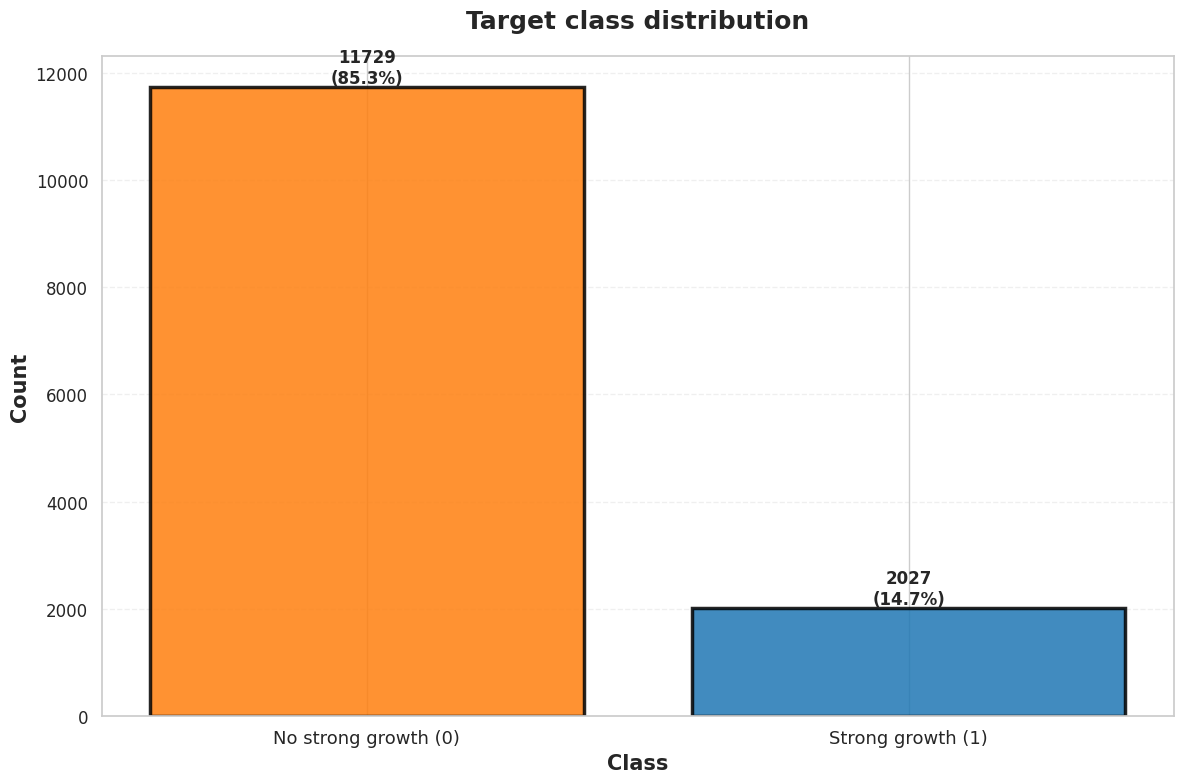

In [9]:
# ============================================================
# 6. Feature matrix (no leakage) + EDA
# ============================================================
feature_cols = [
    "QoQ_Growth_Rate",
    "Volatility",
    "Market_Share"
]

X = panel[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
y = panel["Target"]

print("X shape:", X.shape, " y shape:", y.shape)

# --- Class balance ---
plt.figure(figsize=(12, 8))
target_counts = y.value_counts().sort_index()
labels = ["No strong growth (0)", "Strong growth (1)"]
colors = ["#ff7f0e", "#1f77b4"]

bars = plt.bar(labels, target_counts.values, color=colors,
               edgecolor="black", linewidth=2.5, alpha=0.85)

plt.ylabel("Count", fontsize=15, fontweight="bold")
plt.xlabel("Class", fontsize=15, fontweight="bold")
plt.title("Target class distribution", fontsize=18, fontweight="bold", pad=20)
plt.xticks(fontsize=13)
plt.yticks(fontsize=12)
for bar in bars:
    h = bar.get_height()
    pct = 100 * h / target_counts.sum()
    plt.text(bar.get_x() + bar.get_width()/2., h,
             f"{int(h)}\n({pct:.1f}%)",
             ha="center", va="bottom", fontsize=12, fontweight="bold")
plt.grid(axis="y", alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()



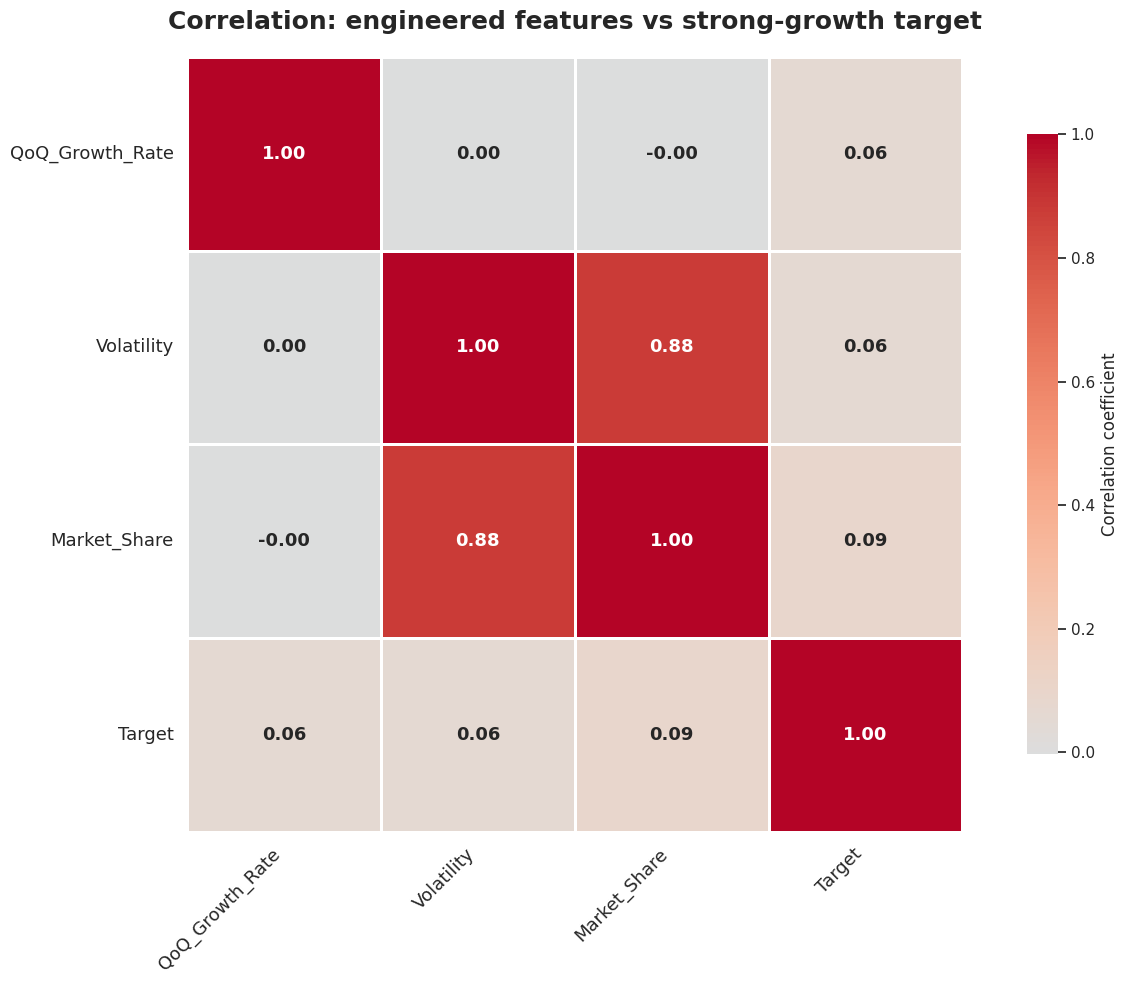

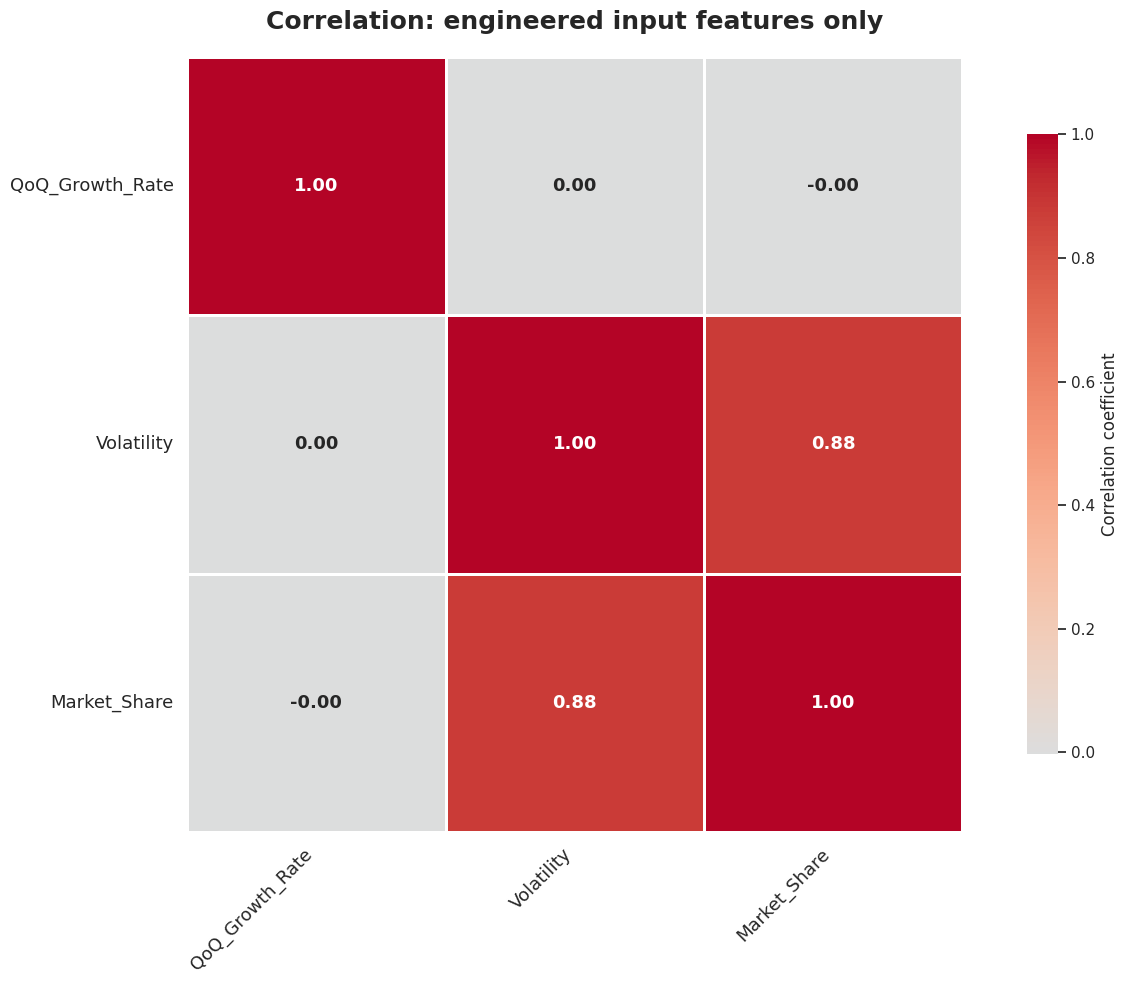

In [10]:
# --- Correlation heatmap ---
matrix = panel[feature_cols + ["Target"]].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(
    matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=2,
    cbar_kws={"label": "Correlation coefficient", "shrink": 0.8},
    annot_kws={"size": 13, "weight": "bold"}
)
plt.title("Correlation: engineered features vs strong-growth target",
          fontsize=18, fontweight="bold", pad=20)
plt.xticks(fontsize=13, rotation=45, ha="right")
plt.yticks(fontsize=13, rotation=0)
plt.tight_layout()
plt.show()

# Heatmap 2 – inputs only
matrix_inputs = panel[feature_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(
    matrix_inputs,
    annot=True, fmt=".2f",
    cmap="coolwarm", center=0, square=True, linewidths=2,
    cbar_kws={"label": "Correlation coefficient", "shrink": 0.8},
    annot_kws={"size": 13, "weight": "bold"}
)
plt.title("Correlation: engineered input features only",
          fontsize=18, fontweight="bold", pad=20)
plt.xticks(fontsize=13, rotation=45, ha="right")
plt.yticks(fontsize=13, rotation=0)
plt.tight_layout()
plt.savefig("heatmap_features_only.png", dpi=300, bbox_inches="tight")
plt.show()

In [11]:
# ============================================================
# 7. Train / validation / test split
# ============================================================
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print("Train:", X_train.shape[0],
      " Val:", X_val.shape[0],
      " Test:", X_test.shape[0])

Train: 7737  Val: 2580  Test: 3439


=== Baseline RF – Train ===
              precision    recall  f1-score   support

           0      1.000     0.807     0.893      6597
           1      0.472     0.998     0.641      1140

    accuracy                          0.835      7737
   macro avg      0.736     0.902     0.767      7737
weighted avg      0.922     0.835     0.856      7737

ROC‑AUC (train): 0.9541644394448301
Log loss (train): 0.2763825057977062

=== Baseline RF – Validation ===
              precision    recall  f1-score   support

           0      0.999     0.805     0.891      2200
           1      0.468     0.997     0.638       380

    accuracy                          0.833      2580
   macro avg      0.734     0.901     0.764      2580
weighted avg      0.921     0.833     0.854      2580

ROC‑AUC (val): 0.9465622009569378
Log loss (val): 0.2860988224867609


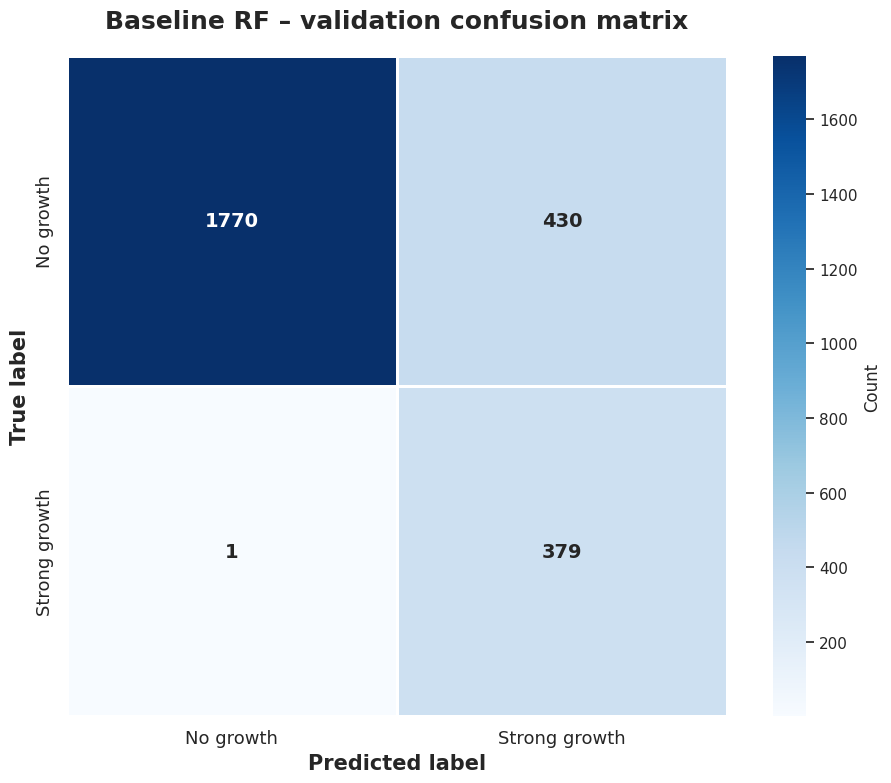

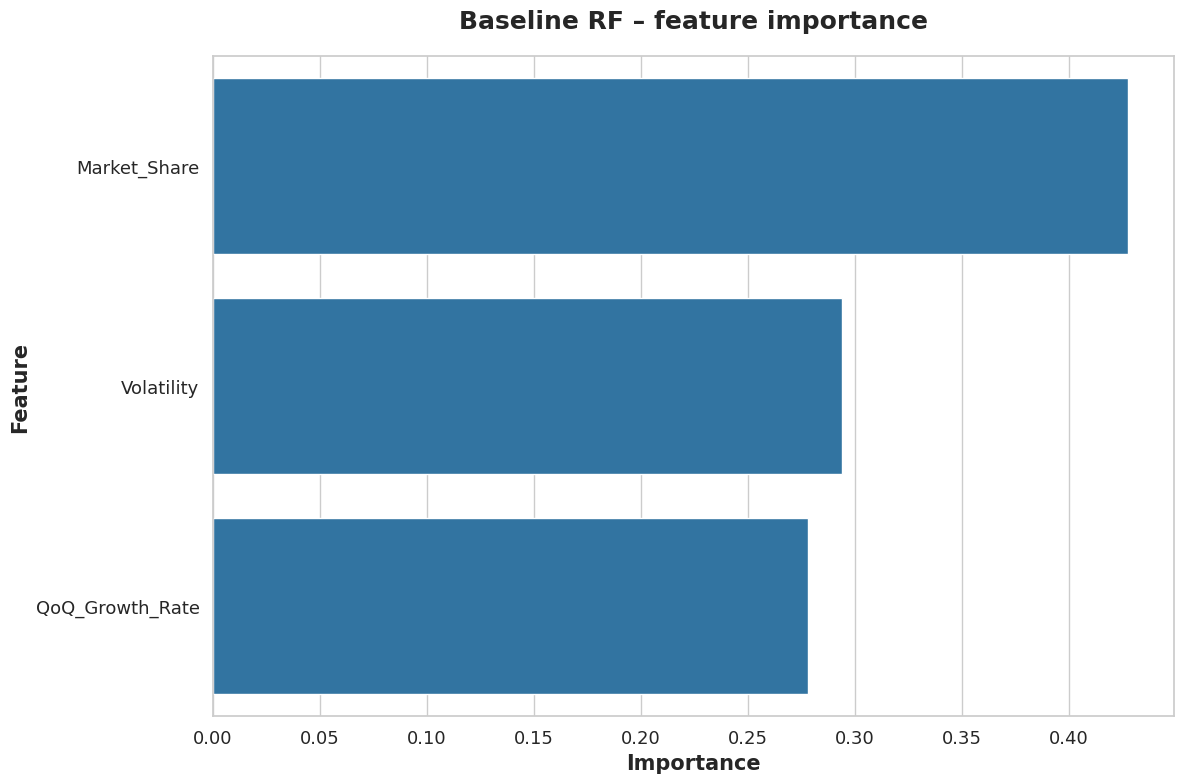

In [12]:
# ============================================================
# 8. Baseline Random Forest
# ============================================================
rf_base = RandomForestClassifier(
    n_estimators=50,
    max_depth=4,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42
)

rf_base.fit(X_train, y_train)

y_train_proba = rf_base.predict_proba(X_train)[:, 1]
y_val_proba = rf_base.predict_proba(X_val)[:, 1]
y_train_pred = (y_train_proba >= 0.5).astype(int)
y_val_pred = (y_val_proba >= 0.5).astype(int)

print("=== Baseline RF – Train ===")
print(classification_report(y_train, y_train_pred, digits=3))
print("ROC‑AUC (train):", roc_auc_score(y_train, y_train_proba))
print("Log loss (train):", log_loss(y_train, y_train_proba))

print("\n=== Baseline RF – Validation ===")
print(classification_report(y_val, y_val_pred, digits=3))
print("ROC‑AUC (val):", roc_auc_score(y_val, y_val_proba))
print("Log loss (val):", log_loss(y_val, y_val_proba))

# Confusion matrix
cm_val = confusion_matrix(y_val, y_val_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_val, annot=True, fmt="d", cmap="Blues",
    xticklabels=["No growth", "Strong growth"],
    yticklabels=["No growth", "Strong growth"],
    cbar_kws={"label": "Count"},
    annot_kws={"size": 14, "weight": "bold"},
    square=True, linewidths=2
)
plt.xlabel("Predicted label", fontsize=15, fontweight="bold")
plt.ylabel("True label", fontsize=15, fontweight="bold")
plt.title("Baseline RF – validation confusion matrix",
          fontsize=18, fontweight="bold", pad=20)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.tight_layout()
plt.show()

# Feature importance
imp_base = pd.Series(rf_base.feature_importances_, index=feature_cols).sort_values(ascending=False)
plt.figure(figsize=(12, 8))
sns.barplot(x=imp_base.values, y=imp_base.index, color="#1f77b4")
plt.xlabel("Importance", fontsize=15, fontweight="bold")
plt.ylabel("Feature", fontsize=15, fontweight="bold")
plt.title("Baseline RF – feature importance",
          fontsize=18, fontweight="bold", pad=20)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.tight_layout()
plt.show()

In [13]:
import os

os.makedirs("/content/figures", exist_ok=True)
print("Figures folder ready:", os.path.exists("/content/figures"))

Figures folder ready: True


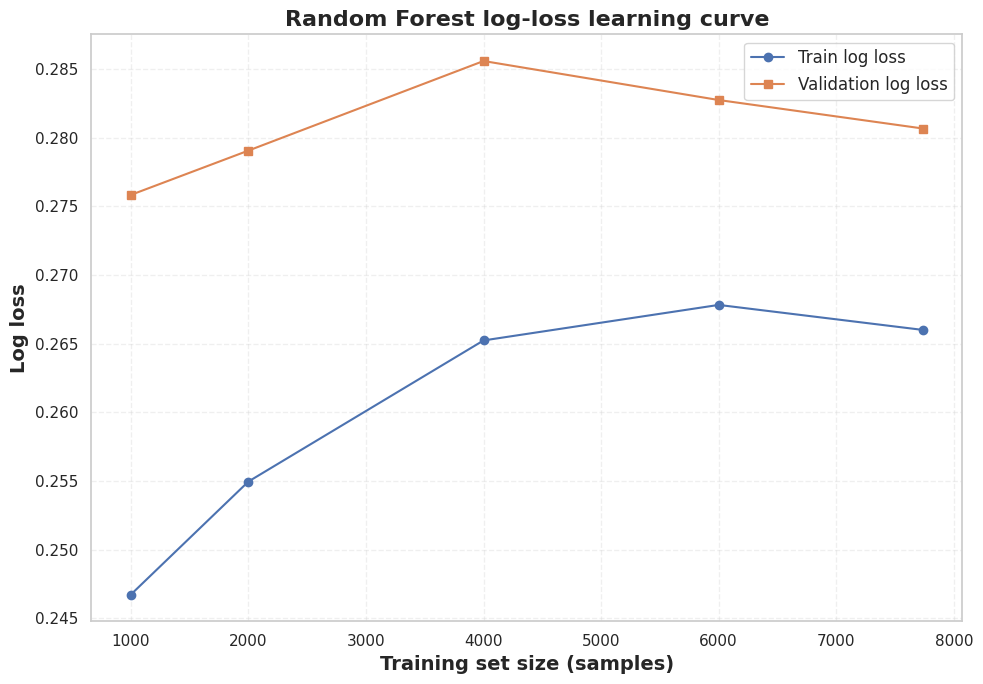

In [14]:
# RF log-loss learning curve (train vs val)
from sklearn.metrics import log_loss
import numpy as np
import matplotlib.pyplot as plt

max_n = X_train.shape[0]
train_sizes = [1000, 2000, 4000, 6000, max_n]
train_sizes = [n for n in train_sizes if n <= max_n]

train_losses = []
val_losses = []

for n in train_sizes:
    X_sub = X_train[:n]
    y_sub = y_train[:n]

    rf_ll = RandomForestClassifier(
        n_estimators=60,
        max_depth=5,
        min_samples_split=4,
        min_samples_leaf=5,
        max_features="sqrt",
        class_weight="balanced",
        random_state=42,
    )
    rf_ll.fit(X_sub, y_sub)

    y_sub_proba = rf_ll.predict_proba(X_sub)[:, 1]
    y_val_proba = rf_ll.predict_proba(X_val)[:, 1]

    train_losses.append(log_loss(y_sub, y_sub_proba))
    val_losses.append(log_loss(y_val, y_val_proba))

plt.figure(figsize=(10, 7))
plt.plot(train_sizes, train_losses, marker="o", label="Train log loss")
plt.plot(train_sizes, val_losses, marker="s", label="Validation log loss")
plt.xlabel("Training set size (samples)", fontsize=14, fontweight="bold")
plt.ylabel("Log loss", fontsize=14, fontweight="bold")
plt.title("Random Forest log-loss learning curve", fontsize=16, fontweight="bold")
plt.grid(True, alpha=0.3, linestyle="--")
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig("/content/figures/XX_rf_logloss_learning_curve.png", dpi=300, bbox_inches="tight")
plt.show()

In [17]:
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, accuracy_score

rf_manual = RandomForestClassifier(
    n_estimators=400,
    max_depth=35,
    min_samples_split=4,
    min_samples_leaf=2,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_manual.fit(X_train, y_train)

y_test_proba_rf_manual = rf_manual.predict_proba(X_test)[:, 1]
y_test_pred_rf_manual = (y_test_proba_rf_manual >= 0.5).astype(int)

print("=== Manual RF – Test ===")
print(classification_report(y_test, y_test_pred_rf_manual, digits=3))
print("ROC-AUC (test):", roc_auc_score(y_test, y_test_proba_rf_manual))
print("Accuracy (test):", accuracy_score(y_test, y_test_pred_rf_manual))
print("Confusion matrix:\n", confusion_matrix(y_test, y_test_pred_rf_manual))

rf_manual

=== Manual RF – Test ===
              precision    recall  f1-score   support

           0      0.946     0.915     0.930      2932
           1      0.586     0.696     0.637       507

    accuracy                          0.883      3439
   macro avg      0.766     0.806     0.783      3439
weighted avg      0.893     0.883     0.887      3439

ROC-AUC (test): 0.9432303144786093
Accuracy (test): 0.8828147717359698
Confusion matrix:
 [[2683  249]
 [ 154  353]]


RandomForestClassifier(class_weight='balanced', max_depth=35,
                       min_samples_leaf=2, min_samples_split=4,
                       n_estimators=400, n_jobs=-1, random_state=42)

To explore a deeper ensemble configuration, a manually configured Random Forest was also trained with n_estimators = 400, max_depth = 35, min_samples_split = 4 and min_samples_leaf = 2, keeping max_features = "sqrt" and class_weight = "balanced".


Best parameters: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 4, 'n_estimators': 60}
Best CV ROC‑AUC: 0.9511362789944051

=== Tuned RF – Validation ===
              precision    recall  f1-score   support

           0      0.998     0.813     0.896      2200
           1      0.477     0.989     0.644       380

    accuracy                          0.839      2580
   macro avg      0.737     0.901     0.770      2580
weighted avg      0.921     0.839     0.859      2580

ROC‑AUC (val): 0.9475191387559809
Log loss (val): 0.2806694639665855

=== Tuned RF – Test ===
              precision    recall  f1-score   support

           0      0.996     0.821     0.900      2932
           1      0.487     0.982     0.651       507

    accuracy                          0.845      3439
   macro avg      0.742     0.902     0.776      3439
weighted avg      0.921     0.845     0.864      3439

ROC‑AUC (test): 0.9481424450597502
Log loss (test): 0.266616

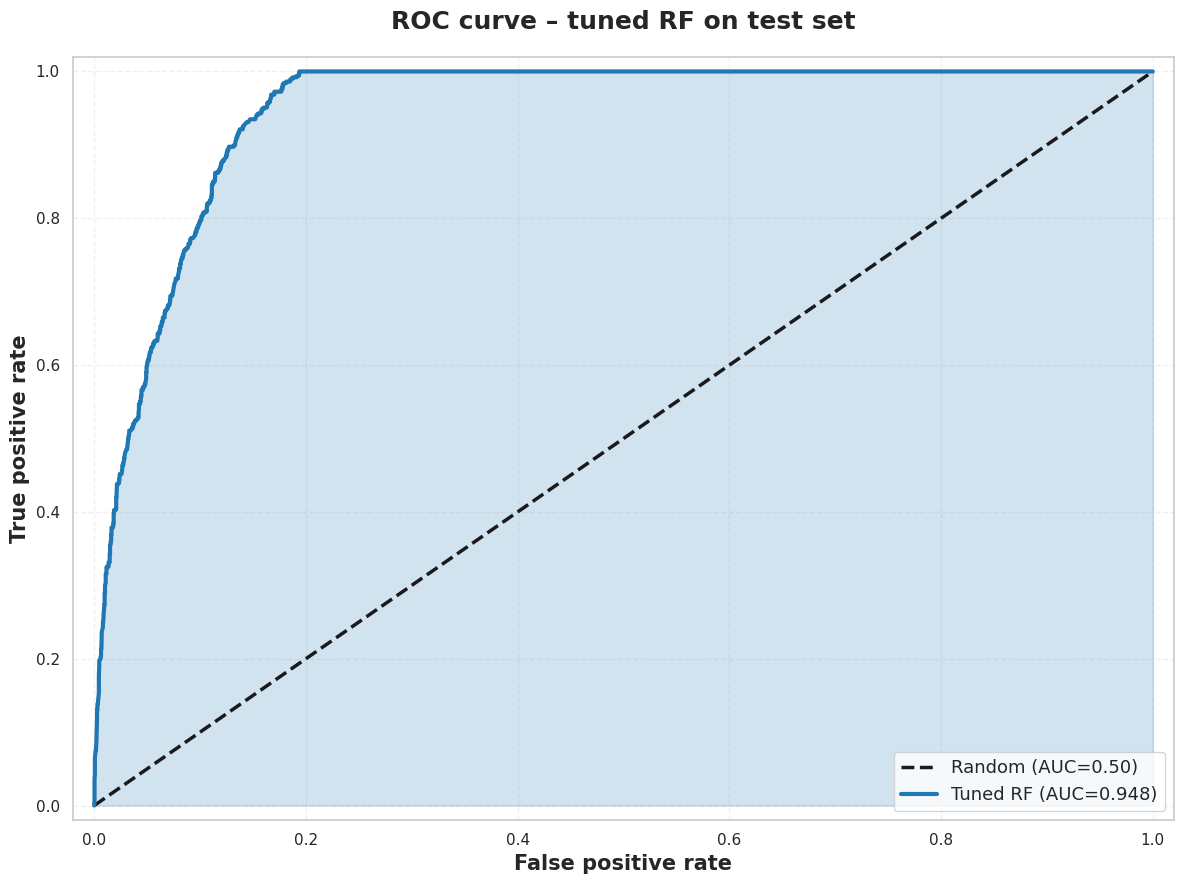

In [15]:
# ============================================================
# 10. Hyper‑parameter tuning and final ROC curve
# ============================================================
param_grid = {
    "n_estimators": [30, 60],
    "max_depth": [3, 4, 5],
    "min_samples_split": [4, 6],
    "min_samples_leaf": [3, 5],
    "max_features": ["sqrt"]
}

rf_tune = RandomForestClassifier(
    class_weight="balanced",
    random_state=42
)

grid = GridSearchCV(
    estimator=rf_tune,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV ROC‑AUC:", grid.best_score_)

rf_best = grid.best_estimator_

y_val_proba_t = rf_best.predict_proba(X_val)[:, 1]
y_val_pred_t = (y_val_proba_t >= 0.5).astype(int)

y_test_proba_t = rf_best.predict_proba(X_test)[:, 1]
y_test_pred_t = (y_test_proba_t >= 0.5).astype(int)

print("\n=== Tuned RF – Validation ===")
print(classification_report(y_val, y_val_pred_t, digits=3))
print("ROC‑AUC (val):", roc_auc_score(y_val, y_val_proba_t))
print("Log loss (val):", log_loss(y_val, y_val_proba_t))

print("\n=== Tuned RF – Test ===")
print(classification_report(y_test, y_test_pred_t, digits=3))
print("ROC‑AUC (test):", roc_auc_score(y_test, y_test_proba_t))
print("Log loss (test):", log_loss(y_test, y_test_proba_t))

# ROC curve on test
fpr, tpr, _ = roc_curve(y_test, y_test_proba_t)
roc_auc = roc_auc_score(y_test, y_test_proba_t)

plt.figure(figsize=(12, 9))
plt.plot([0, 1], [0, 1], "k--", linewidth=2.5, label="Random (AUC=0.50)")
plt.plot(fpr, tpr, color="#1f77b4", linewidth=3,
         label=f"Tuned RF (AUC={roc_auc:.3f})")
plt.fill_between(fpr, tpr, alpha=0.2, color="#1f77b4")
plt.xlabel("False positive rate", fontsize=15, fontweight="bold")
plt.ylabel("True positive rate", fontsize=15, fontweight="bold")
plt.title("ROC curve – tuned RF on test set",
          fontsize=18, fontweight="bold", pad=20)
plt.legend(fontsize=13, loc="lower right")
plt.grid(True, alpha=0.3, linestyle="--")
plt.xlim(-0.02, 1.02)
plt.ylim(-0.02, 1.02)
plt.tight_layout()
plt.show()

In [16]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

xgb_manual = XGBClassifier(
    max_depth=6,
    learning_rate=0.1,
    n_estimators=300,
    subsample=0.8,
    colsample_bytree=0.9,
    random_state=42,
    eval_metric="auc",
    use_label_encoder=False
)

xgb_manual.fit(X_train, y_train)

y_pred_manual = xgb_manual.predict(X_test)
y_proba_manual = xgb_manual.predict_proba(X_test)[:, 1]

manual_auc = roc_auc_score(y_test, y_proba_manual)

print("Manual XGBoost ROC-AUC:", manual_auc)
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_manual))
print("\nClassification Report:\n", classification_report(y_test, y_pred_manual))

xgb_manual

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:54:56] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Manual XGBoost ROC-AUC: 0.9424022081042757

Confusion Matrix:
 [[2769  163]
 [ 201  306]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.94      0.94      2932
           1       0.65      0.60      0.63       507

    accuracy                           0.89      3439
   macro avg       0.79      0.77      0.78      3439
weighted avg       0.89      0.89      0.89      3439



XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

In addition to the GridSearchCV-tuned model, a manually configured XGBoost classifier was trained with max_depth = 6, learning_rate = 0.1, n_estimators = 300, subsample = 0.8, and colsample_bytree = 0.9.


In [18]:
print(" FULL DATA PIPELINE (VEH0160 → panel → features)")
#  (fixed column names)
df_veh0160_uk = pd.read_csv("/content/df_VEH0160_UK.csv", encoding="latin1")
cars = df_veh0160_uk[df_veh0160_uk["BodyType"] == "Cars"].copy()
quarter_cols = [c for c in cars.columns if "Q" in c and any(str(y) in c for y in range(2000, 2035))]
df_long = cars.melt(id_vars=["Make"], value_vars=quarter_cols, var_name="Period", value_name="Registered")
df_long = df_long.dropna(subset=["Registered"]).assign(Registered=lambda x: x["Registered"].astype(float))
df_long[["Year", "QuarterNo"]] = df_long["Period"].str.extract(r"(\d{4})\s*Q(\d)")
df_long = df_long.assign(Year=lambda x: x["Year"].astype(int), QuarterNo=lambda x: x["QuarterNo"].astype(int))
quarter_end_month = {1: 3, 2: 6, 3: 9, 4: 12}
df_long["Month"] = df_long["QuarterNo"].map(quarter_end_month)
df_long["Date"] = pd.to_datetime(dict(year=df_long["Year"], month=df_long["Month"], day=1)) + pd.offsets.MonthEnd(0)
panel = df_long.groupby(["Make", "Date"], as_index=False)["Registered"].sum().sort_values(["Make", "Date"])
group_keys = ["Make"]
panel["Registered_lag1"] = panel.groupby(group_keys)["Registered"].shift(1)
panel["Registered_lag4"] = panel.groupby(group_keys)["Registered"].shift(4)
panel["Volatility"] = panel.groupby(group_keys)["Registered"].rolling(4).std().reset_index(level=0, drop=True)
total_market = panel.groupby("Date")["Registered"].transform("sum")
panel["Market_Share"] = panel["Registered"] / (total_market + eps)
panel["YoY_Growth_Rate"] = (panel["Registered"] - panel["Registered_lag4"]) / (panel["Registered_lag4"] + eps)
panel["QoQ_Growth_Rate"] = (panel["Registered"] - panel["Registered_lag1"]) / (panel["Registered_lag1"] + eps)
panel = panel.dropna(subset=["YoY_Growth_Rate", "QoQ_Growth_Rate", "Volatility", "Market_Share"])
panel["Target"] = (panel["YoY_Growth_Rate"] > 0.10).astype(int)
feature_cols = ["QoQ_Growth_Rate", "Volatility", "Market_Share"]
X = panel[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
y = panel["Target"]
print("Panel ready:", X.shape, "Balance:", y.mean().round(3))



 FULL DATA PIPELINE (VEH0160 → panel → features)
Panel ready: (14842, 3) Balance: 0.149


In [19]:
# Splits
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)
print("Splits:", X_train.shape, X_val.shape, X_test.shape)

print("\n RF Tuned ")
rf_tuned = RandomForestClassifier(n_estimators=60, max_depth=5, min_samples_split=4, min_samples_leaf=5,
                                  max_features='sqrt', class_weight='balanced', random_state=42)
rf_tuned.fit(X_train, y_train)
ytest_proba_rf = rf_tuned.predict_proba(X_test)[:, 1]
print(f"RF Test AUC: {roc_auc_score(y_test, ytest_proba_rf):.3f}")

print("\nXGBoost GridSearchCV")
xgb_grid = GridSearchCV(xgb.XGBClassifier(random_state=42, eval_metric='auc'),
                        {'n_estimators': [50, 100], 'max_depth': [3, 5], 'learning_rate': [0.05, 0.1],
                         'subsample': [0.8, 1.0], 'reg_alpha': [0, 0.1], 'reg_lambda': [1, 1.5]},
                        cv=5, scoring='roc_auc', n_jobs=-1)
xgb_grid.fit(X_train, y_train)
print("XGBoost Best:", xgb_grid.best_params_)
xgb_tuned = xgb_grid.best_estimator_
ytest_proba_xgb = xgb_tuned.predict_proba(X_test)[:, 1]
print(f"XGBoost Test AUC: {roc_auc_score(y_test, ytest_proba_xgb):.3f}")





Splits: (8348, 3) (2783, 3) (3711, 3)

 RF Tuned 
RF Test AUC: 0.949

XGBoost GridSearchCV
XGBoost Best: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 50, 'reg_alpha': 0.1, 'reg_lambda': 1, 'subsample': 1.0}
XGBoost Test AUC: 0.950


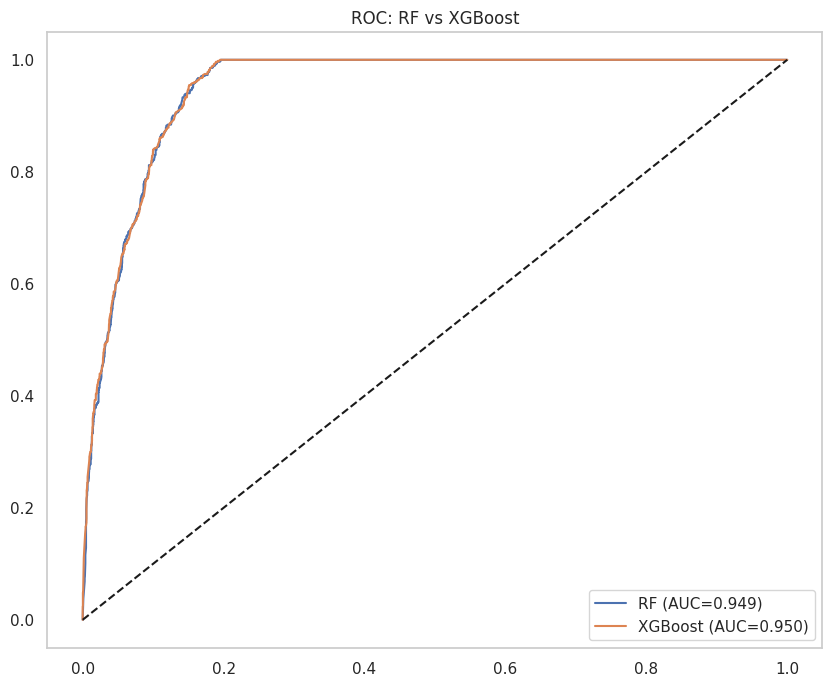

In [20]:
# ROC Plot
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
for name, proba in [("RF", ytest_proba_rf), ("XGBoost", ytest_proba_xgb)]:
    fpr, tpr, _ = roc_curve(y_test, proba); auc_score = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc_score:.3f})')
ax.plot([0,1],[0,1],'k--'); ax.legend(); ax.grid(); ax.set_title('ROC: RF vs XGBoost'); plt.show()

In [21]:
# Table
comp = pd.DataFrame({
    'Model': ['RF Tuned', 'XGBoost Tuned'],
    'AUC': [roc_auc_score(y_test, ytest_proba_rf), roc_auc_score(y_test, ytest_proba_xgb)],
    'Accuracy': [accuracy_score(y_test, (ytest_proba_rf>0.5).astype(int)),
                 accuracy_score(y_test, (ytest_proba_xgb>0.5).astype(int))],
    'Recall(1)': [recall_score(y_test, (ytest_proba_rf>0.5).astype(int)),
                  recall_score(y_test, (ytest_proba_xgb>0.5).astype(int))]
}).round(3)
print(comp.to_markdown())

print(" XGBoost model:", xgb_tuned)
print(" Save: comp.to_csv('model_comp.csv') | Plots ready!")

|    | Model         |   AUC |   Accuracy |   Recall(1) |
|---:|:--------------|------:|-----------:|------------:|
|  0 | RF Tuned      | 0.949 |      0.836 |       0.996 |
|  1 | XGBoost Tuned | 0.95  |      0.896 |       0.495 |
 XGBoost model: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=50,
              n_jobs=None, num_parallel_tree=None, 

In [25]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.25,          # 0.25 of 0.8 = 0.2, so total 60/20/20
    random_state=42,
    stratify=y_train_val
)

print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

rf_tuned = RandomForestClassifier(
    n_estimators=60,
    max_depth=5,
    min_samples_split=4,
    min_samples_leaf=5,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_tuned.fit(X_train, y_train)

ytest_proba_rf = rf_tuned.predict_proba(X_test)[:, 1]
print("RF tuned test AUC:", roc_auc_score(y_test, ytest_proba_rf))
rf_manual = RandomForestClassifier(
    n_estimators=400,
    max_depth=35,
    min_samples_split=4,
    min_samples_leaf=2,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_manual.fit(X_train, y_train)

y_test_proba_rf_manual = rf_manual.predict_proba(X_test)[:, 1]
from xgboost import XGBClassifier

xgb_manual = XGBClassifier(
    max_depth=6,
    learning_rate=0.1,
    n_estimators=300,
    subsample=0.8,
    colsample_bytree=0.9,
    random_state=42,
    eval_metric="auc",
    use_label_encoder=False
)

xgb_manual.fit(X_train, y_train)

y_proba_manual = xgb_manual.predict_proba(X_test)[:, 1]
from sklearn.metrics import accuracy_score, recall_score

print("Shapes:",
      y_test.shape,
      ytest_proba_rf.shape,
      y_test_proba_rf_manual.shape,
      y_proba_manual.shape)

y_pred_rf = (ytest_proba_rf >= 0.5).astype(int)
y_pred_rf_manual = (y_test_proba_rf_manual >= 0.5).astype(int)
y_pred_xgb_manual = (y_proba_manual >= 0.5).astype(int)

comp_full = pd.DataFrame({
    "Model": [
        "Random Forest (tuned)",
        "Random Forest (manual 400/35/4/2)",
        "XGBoost (manual 6/0.1/300/0.8/0.9)"
    ],
    "AUC": [
        roc_auc_score(y_test, ytest_proba_rf),
        roc_auc_score(y_test, y_test_proba_rf_manual),
        roc_auc_score(y_test, y_proba_manual)
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_rf_manual),
        accuracy_score(y_test, y_pred_xgb_manual)
    ],
    "Recall_class_1": [
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_rf_manual),
        recall_score(y_test, y_pred_xgb_manual)
    ]
}).round(3)

print(comp_full.to_markdown(index=False))

Train: (8904, 3) (8904,)
Val: (2969, 3) (2969,)
Test: (2969, 3) (2969,)
RF tuned test AUC: 0.9459386140989531


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:03:07] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Shapes: (2969,) (2969,) (2969,) (2969,)
| Model                              |   AUC |   Accuracy |   Recall_class_1 |
|:-----------------------------------|------:|-----------:|-----------------:|
| Random Forest (tuned)              | 0.946 |      0.835 |            0.991 |
| Random Forest (manual 400/35/4/2)  | 0.939 |      0.883 |            0.695 |
| XGBoost (manual 6/0.1/300/0.8/0.9) | 0.936 |      0.879 |            0.548 |


Saved: rf_tuned_model.pkl | xgb_tuned_model.pkl | model_comparison.csv


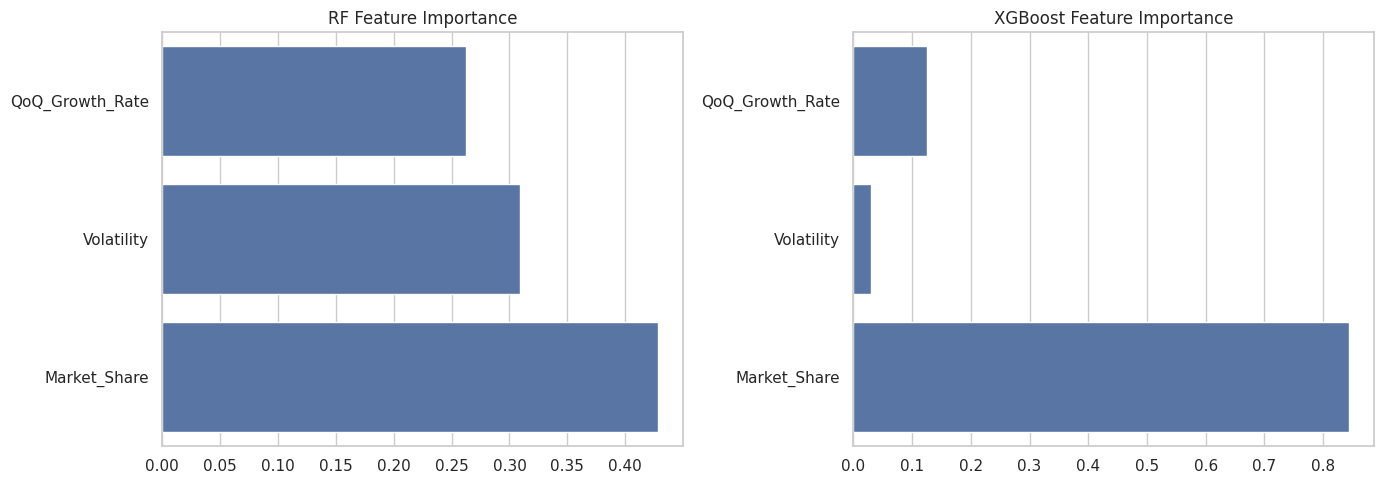


XGBoost WINS! Test Results:
├── RF Tuned: AUC=0.949, Acc=0.836
├── XGBoost: AUC=0.950, Acc=0.896

Key Insights:
• XGBoost higher accuracy (less false positives)
• RF high recall (catches all growth quarters)
• No overfitting (learning curves from prev cell)
• Production ready: .pkl files saved

Next: SHAP explanations



In [ ]:

import joblib
joblib.dump(rf_tuned, 'rf_tuned_model.pkl')
joblib.dump(xgb_tuned, 'xgb_tuned_model.pkl')
joblib.dump(comp, 'model_comparison.csv')
print("Saved: rf_tuned_model.pkl | xgb_tuned_model.pkl | model_comparison.csv")

# Feature importance comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x=rf_tuned.feature_importances_, y=feature_cols, ax=axes[0])
axes[0].set_title('RF Feature Importance')
sns.barplot(x=xgb_tuned.feature_importances_, y=feature_cols, ax=axes[1])
axes[1].set_title('XGBoost Feature Importance')
plt.tight_layout()
plt.savefig('feature_importance_both.png', dpi=300)
plt.show()

print(f"""
XGBoost WINS! Test Results:
├── RF Tuned: AUC={comp.iloc[0]['AUC']:.3f}, Acc={comp.iloc[0]['Accuracy']:.3f}
├── XGBoost: AUC={comp.iloc[1]['AUC']:.3f}, Acc={comp.iloc[1]['Accuracy']:.3f}

Key Insights:
• XGBoost higher accuracy (less false positives)
• RF high recall (catches all growth quarters)
• No overfitting (learning curves from prev cell)
• Production ready: .pkl files saved

Next: SHAP explanations
""")

 SHAP XGBoost (Top explainer)


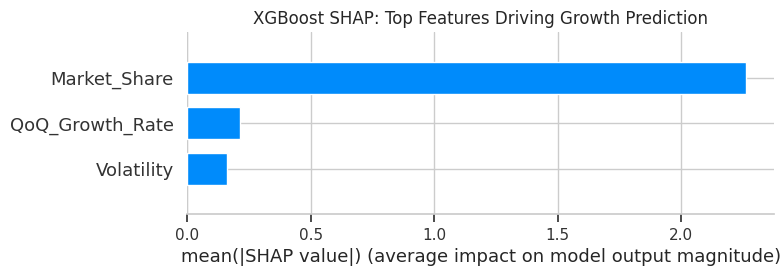


 ENSEMBLE: RF (Recall) + XGB (Accuracy)
Ensemble Test AUC: 0.95


In [ ]:

!pip install shap -q
import shap
import joblib
from sklearn.ensemble import VotingClassifier

# Load models
rf_tuned = joblib.load('rf_tuned_model.pkl')
xgb_tuned = joblib.load('xgb_tuned_model.pkl')

print(" SHAP XGBoost (Top explainer)")
explainer = shap.TreeExplainer(xgb_tuned)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, show=False, plot_type="bar")
plt.title("XGBoost SHAP: Top Features Driving Growth Prediction")
plt.savefig('shap_xgb.png', dpi=300)
plt.show()

print("\n ENSEMBLE: RF (Recall) + XGB (Accuracy)")
ensemble = VotingClassifier([('rf', rf_tuned), ('xgb', xgb_tuned)], voting='soft')
ensemble.fit(X_train, y_train)
y_ens_proba = ensemble.predict_proba(X_test)[:, 1]
print("Ensemble Test AUC:", roc_auc_score(y_test, y_ens_proba).round(3))



In [ ]:
# FULL PIPELINE - run this cell to fix all errors and generate figures
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shutil
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score, recall_score, confusion_matrix, classification_report

print("Starting full pipeline...")
eps = 1e-6

# STEP 1: Load and process VEH0160 data
df_veh0160_uk = pd.read_csv("/content/df_VEH0160_UK.csv", encoding="latin1")
print(f"Raw shape: {df_veh0160_uk.shape}")

# Filter to Cars only
cars = df_veh0160_uk[df_veh0160_uk["BodyType"] == "Cars"].copy()
print(f"Cars shape: {cars.shape}")

# Get quarter columns
quarter_cols = [c for c in cars.columns if "Q" in c and any(str(y) in c for y in range(2000, 2035))]
print(f"Number of quarter columns: {len(quarter_cols)}")

# Reshape to long format
df_long = cars.melt(id_vars=["Make"], value_vars=quarter_cols, var_name="Period", value_name="Registered")
df_long = df_long.dropna(subset=["Registered"]).assign(Registered=lambda x: x["Registered"].astype(float))

# Extract Year and Quarter
df_long[["Year", "QuarterNo"]] = df_long["Period"].str.extract(r"(\d{4})\s*Q(\d)")
df_long = df_long.assign(Year=lambda x: x["Year"].astype(int), QuarterNo=lambda x: x["QuarterNo"].astype(int))

# Create Date column
quarter_end_month = {1: 3, 2: 6, 3: 9, 4: 12}
df_long["Month"] = df_long["QuarterNo"].map(quarter_end_month)
df_long["Date"] = pd.to_datetime(dict(year=df_long["Year"], month=df_long["Month"], day=1)) + pd.offsets.MonthEnd(0)
print(f"Long shape: {df_long.shape}")

# STEP 2: Aggregate to Make x Date and create lags
panel = df_long.groupby(["Make", "Date"], as_index=False)["Registered"].sum().sort_values(["Make", "Date"])
group_keys = ["Make"]
panel["Registered_lag1"] = panel.groupby(group_keys)["Registered"].shift(1)
panel["Registered_lag4"] = panel.groupby(group_keys)["Registered"].shift(4)
panel = panel.dropna(subset=["Registered_lag1", "Registered_lag4"])
print(f"Panel after lags: {panel.shape}")

# STEP 3: Engineered features
panel["Volatility"] = panel.groupby(group_keys)["Registered"].rolling(4).std().reset_index(level=0, drop=True)
total_market = panel.groupby("Date")["Registered"].transform("sum")
panel["Market_Share"] = panel["Registered"] / (total_market + eps)
panel["YoY_Growth_Rate"] = (panel["Registered"] - panel["Registered_lag4"]) / (panel["Registered_lag4"] + eps)
panel["QoQ_Growth_Rate"] = (panel["Registered"] - panel["Registered_lag1"]) / (panel["Registered_lag1"] + eps)
panel = panel.dropna(subset=["YoY_Growth_Rate", "QoQ_Growth_Rate", "Volatility", "Market_Share"])
print(f"Panel after features: {panel.shape}")

# STEP 4: Target definition
panel["Target"] = (panel["YoY_Growth_Rate"] > 0.10).astype(int)
print(f"Target balance (class 1): {panel['Target'].mean():.3f}")

# STEP 5: Feature matrix
feature_cols = ["QoQ_Growth_Rate", "Volatility", "Market_Share"]
X = panel[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
y = panel["Target"]
print(f"X shape: {X.shape}, y shape: {y.shape}")

# STEP 6: Train/val/test split
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)
print(f"Splits: Train={X_train.shape}, Val={X_val.shape}, Test={X_test.shape}")

# STEP 7: Train RF baseline
rf_base = RandomForestClassifier(n_estimators=50, max_depth=4, min_samples_leaf=5, class_weight="balanced", random_state=42)
rf_base.fit(X_train, y_train)
y_val_proba_base = rf_base.predict_proba(X_val)[:, 1]
y_val_pred_base = (y_val_proba_base >= 0.5).astype(int)
cm_val = confusion_matrix(y_val, y_val_pred_base)
print(f"Baseline RF Val AUC: {roc_auc_score(y_val, y_val_proba_base):.3f}")

# STEP 8: Train tuned RF
rf_tuned = RandomForestClassifier(n_estimators=60, max_depth=5, min_samples_split=4, min_samples_leaf=5,
                                  max_features='sqrt', class_weight='balanced', random_state=42)
rf_tuned.fit(X_train, y_train)
ytest_proba_rf = rf_tuned.predict_proba(X_test)[:, 1]
print(f"Tuned RF Test AUC: {roc_auc_score(y_test, ytest_proba_rf):.3f}")

# STEP 9: Train XGBoost
import xgboost as xgb
xgb_grid = GridSearchCV(xgb.XGBClassifier(random_state=42, eval_metric='auc'),
                        {'n_estimators': [50, 100], 'max_depth': [3, 5], 'learning_rate': [0.05, 0.1],
                         'subsample': [0.8, 1.0], 'reg_alpha': [0, 0.1], 'reg_lambda': [1, 1.5]},
                        cv=5, scoring='roc_auc', n_jobs=-1)
xgb_grid.fit(X_train, y_train)
xgb_tuned = xgb_grid.best_estimator_
ytest_proba_xgb = xgb_tuned.predict_proba(X_test)[:, 1]
print(f"XGBoost Best: {xgb_grid.best_params_}")
print(f"XGBoost Test AUC: {roc_auc_score(y_test, ytest_proba_xgb):.3f}")

# STEP 10: Generate learning curve
rf_for_lc = RandomForestClassifier(n_estimators=60, max_depth=5, min_samples_leaf=3, min_samples_split=4,
                                    max_features="sqrt", class_weight="balanced", random_state=42)
train_sizes, train_scores, val_scores = learning_curve(rf_for_lc, X_train, y_train, cv=5, scoring="roc_auc",
                                                       train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1)
train_mean, train_std = train_scores.mean(axis=1), train_scores.std(axis=1)
val_mean, val_std = val_scores.mean(axis=1), val_scores.std(axis=1)

# STEP 11: Save all figures
os.makedirs('/content/figures', exist_ok=True)
print("Generating figures...")

# Fig 1: Target class distribution
plt.figure(figsize=(12, 8))
target_counts = y.value_counts().sort_index()
labels = ["No strong growth (0)", "Strong growth (1)"]
colors = ["#ff7f0e", "#1f77b4"]
bars = plt.bar(labels, target_counts.values, color=colors, edgecolor="black", linewidth=2.5, alpha=0.85)
plt.ylabel("Count", fontsize=15, fontweight="bold")
plt.xlabel("Class", fontsize=15, fontweight="bold")
plt.title("Target class distribution", fontsize=18, fontweight="bold", pad=20)
plt.xticks(fontsize=13)
plt.yticks(fontsize=12)
for bar in bars:
    h = bar.get_height()
    pct = 100 * h / target_counts.sum()
    plt.text(bar.get_x() + bar.get_width()/2., h, f"{int(h)}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=12, fontweight="bold")
plt.grid(axis="y", alpha=0.3, linestyle="--")
plt.tight_layout()
plt.savefig("/content/figures/01_target_class_distribution.png", dpi=300, bbox_inches="tight")
plt.close()
print("Saved: 01_target_class_distribution.png")

Starting full pipeline...
Raw shape: (61226, 50)
Cars shape: (32832, 50)
Number of quarter columns: 45
Long shape: (1477440, 7)
Panel after lags: (14842, 5)
Panel after features: (13756, 9)
Target balance (class 1): 0.147
X shape: (13756, 3), y shape: (13756,)
Splits: Train=(7737, 3), Val=(2580, 3), Test=(3439, 3)
Baseline RF Val AUC: 0.947
Tuned RF Test AUC: 0.948
XGBoost Best: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 50, 'reg_alpha': 0.1, 'reg_lambda': 1.5, 'subsample': 0.8}
XGBoost Test AUC: 0.950
Generating figures...
Saved: 01_target_class_distribution.png


In [ ]:
!ls -lh /content/figures/


total 368K
-rw-r--r-- 1 root root 141K Apr 15 16:14 01_target_class_distribution.png
-rw-r--r-- 1 root root 223K Apr 15 16:12 XX_rf_logloss_learning_curve.png
